In [1]:
# Instala os pacotes necessários
!pip install feature-engine
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Importa as bibliotecas
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate # cross_validate para validação cruzada
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    roc_auc_score, # Métrica AUC ROC
    average_precision_score # Métrica Average Precision (PR AUC)
)
from sklearn.pipeline import Pipeline
from feature_engine.selection import SmartCorrelatedSelection # Para seleção de features correlacionadas
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier # Classificadores de Ensemble
from sklearn.linear_model import LogisticRegression # Usado como meta-estimador no Stacking

from sklearn import set_config # Usado para configurar as configurações globais do scikit-learn
from sklearn.base import clone # Usado para clonar estimadores
from sklearn.base import BaseEstimator, TransformerMixin # Classes base para transformadores customizados

from itertools import combinations # Para criar interações entre features
from scipy.stats import pointbiserialr # Para calcular a correlação ponto-bisserial

# Configura o pandas para exibir todas as colunas
pd.set_option('display.max_columns', None)
# Configura o scikit-learn para que os transformadores retornem DataFrames do pandas
set_config(transform_output='pandas')

In [3]:
# Define constantes para caminhos de arquivo e semente aleatória
ROOT = "/content/drive/MyDrive/ml-project" # Diretório raiz do projeto (atualize se necessário)
FILE = "smart-contract-dataset.csv" # Nome do arquivo do dataset
SEED = 78 # Semente aleatória para reprodutibilidade

In [4]:
# Carrega o dataset
# Assume que o arquivo CSV está no mesmo diretório que o notebook,
# ou o caminho ROOT precisa ser usado se o arquivo estiver em outro local.
# data = pd.read_csv(os.path.join(ROOT, FILE)) # Descomente se o arquivo estiver no ROOT
data = pd.read_csv(FILE) # Assume que o arquivo está no diretório atual

In [5]:
# Renomeia as colunas para serem mais amigáveis ao Python
# Substitui caracteres especiais por underscores ou representações textuais
data = data.rename(
    columns=lambda col: (
        col
        .replace('<', 'lt') # menor que
        .replace('>', 'gt') # maior que
        .replace('__', '_double_underscore') # underscore duplo
        .replace(':', '_colon') # dois pontos
    )
)

In [6]:
# Separa as features (X) e o alvo (y)
# Seleciona todas as colunas numéricas a partir da 4ª coluna como features
X = data.iloc[:, 3:].select_dtypes(include="number")
# Seleciona a coluna 'label' como a variável alvo
y = data.label

In [7]:
# Divide os dados em conjuntos de treinamento/validação e teste
# Nota: É importante usar 'stratify=y' se as classes forem desbalanceadas,
# o que não foi feito aqui, mas é uma boa prática.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y # Adicionado stratify=y
)

# Divide o conjunto de treinamento/validação em conjuntos de treinamento e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED, stratify=y_train_val # Adicionado stratify=y_train_val
)

# Imprime as dimensões dos datasets resultantes
print("Dimensões dos conjuntos:")
print(f"X_train_val: {X_train_val.shape}, y_train_val: {y_train_val.shape}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Dimensões dos conjuntos:
X_train_val: (29336, 263), y_train_val: (29336,)
X_train: (23468, 263), y_train: (23468,)
X_val:   (5868, 263), y_val:   (5868,)
X_test:  (7335, 263), y_test:  (7335,)


## Definição de Transformadores Customizados e Funções Auxiliares
#### Reutilizamos os transformadores customizados `TreeFeatureSelector` e `SelectiveInteraction` definidos anteriormente.
#### Adicionalmente, uma função `print_cv_results` é definida para exibir os resultados da validação cruzada de forma organizada.

In [8]:
# Transformador customizado para seleção de features baseada na importância de features de uma Decision Tree
class TreeFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=15, random_state=42):
        """
        Inicializa o TreeFeatureSelector.
        Args:
            k (int): Número de features mais importantes a serem selecionadas.
            random_state (int): Semente aleatória para reprodutibilidade da Decision Tree.
        """
        self.k = k
        self.random_state = random_state

    def fit(self, X, y):
        """
        Ajusta o modelo Decision Tree e seleciona as k features mais importantes.
        Args:
            X (pd.DataFrame): Features de entrada.
            y (pd.Series): Variável alvo.
        Returns:
            self: A instância ajustada do transformador.
        """
        self.feature_names_in_ = X.columns # Armazena os nomes das features de entrada
        self.tree_ = DecisionTreeClassifier(random_state=self.random_state)
        self.tree_.fit(X, y)
        importances = self.tree_.feature_importances_
        # Obtém os índices das k features mais importantes (em ordem decrescente de importância)
        indices = np.argsort(importances)[::-1][:self.k]
        self.selected_features_ = self.feature_names_in_[indices] # Armazena os nomes das features selecionadas

        return self

    def transform(self, X):
        """
        Transforma o DataFrame de entrada para manter apenas as features selecionadas.
        Args:
            X (pd.DataFrame): Features de entrada.
        Returns:
            pd.DataFrame: DataFrame contendo apenas as features selecionadas.
        """
        return X[self.selected_features_]


# Transformador customizado para criar features de interação seletivamente
class SelectiveInteraction(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        """
        Inicializa o transformador SelectiveInteraction.
        Args:
            threshold (float): Correlação ponto-bisserial mínima absoluta
                               para uma feature ser considerada para interação.
        """
        self.threshold = threshold
        self.interactions_ = [] # Para armazenar pares de features para interação
        self.feature_corr_ = {} # Para armazenar as correlações calculadas

    def fit(self, X, y):
        """
        Identifica pares de features para interação baseados na sua correlação com o alvo.
        As interações são criadas entre features que têm:
        1. Correlação absoluta com y >= threshold.
        2. Sinais opostos de correlação com y.
        Args:
            X (pd.DataFrame): Features de entrada.
            y (pd.Series): Variável alvo (deve ser binária).
        Returns:
            self: A instância ajustada do transformador.
        """
        X_df = pd.DataFrame(X).copy() # Garante que X seja um DataFrame e cria uma cópia
        y_series = pd.Series(y).copy() # Garante que y seja uma Series e cria uma cópia

        # Garante que o alvo seja binário para a correlação ponto-bisserial
        if not set(np.unique(y_series)).issubset({0, 1}):
            raise ValueError("A variável alvo `y` deve ser binária (0/1) para a correlação ponto-bisserial.")

        # Calcula a correlação ponto-bisserial para cada feature com o alvo
        self.feature_corr_ = {
            col: pointbiserialr(X_df[col], y_series)[0]
            for col in X_df.columns
        }

        # Identifica pares de features para interação
        self.interactions_ = [
            (f1, f2)
            for f1, f2 in combinations(X_df.columns, 2) # Itera sobre todos os pares únicos de colunas
            # Usa .get(key, 0) para evitar KeyError se uma feature não estiver em feature_corr_ (improvável aqui, mas boa prática)
            if abs(self.feature_corr_.get(f1, 0)) >= self.threshold # Verifica a correlação da primeira feature
            and abs(self.feature_corr_.get(f2, 0)) >= self.threshold # Verifica a correlação da segunda feature
            and np.sign(self.feature_corr_.get(f1, 0)) != np.sign(self.feature_corr_.get(f2, 0)) # Verifica sinais opostos
        ]
        # Armazena os nomes das features de entrada para consistência com scikit-learn
        self.feature_names_in_ = X_df.columns
        return self

    def transform(self, X):
        """
        Cria novas features de interação multiplicando os pares de features selecionados.
        Args:
            X (pd.DataFrame): Features de entrada.
        Returns:
            pd.DataFrame: DataFrame com as features originais e as novas features de interação.
        """
        X_df = pd.DataFrame(X).copy() # Garante que X seja um DataFrame e cria uma cópia
        new_features_dict = {}
        # Cria novas features como produto dos pares identificados
        for f1, f2 in self.interactions_:
            # Garante que as features existam no DataFrame de entrada
            if f1 in X_df.columns and f2 in X_df.columns:
                new_features_dict[f"{f1}_x_{f2}"] = X_df[f1] * X_df[f2]

        if not new_features_dict: # Se nenhuma interação foi criada
            return X_df # Retorna o DataFrame original

        # Concatena as novas features de interação com o DataFrame original
        X_new = pd.concat([X_df, pd.DataFrame(new_features_dict, index=X_df.index)], axis=1)
        return X_new

# Função para imprimir os resultados da validação cruzada de forma formatada
def print_cv_results(cv_results):
    """
    Imprime a média e o desvio padrão das métricas de teste de um dicionário
    de resultados da validação cruzada (gerado por cross_validate).
    """
    print("\nResultados da Validação Cruzada:")
    for key, values in cv_results.items():
        if key.startswith("test_"): # Considera apenas as métricas do conjunto de teste de cada fold
            metric = key.replace("test_", "").replace("_", " ").capitalize() # Formata o nome da métrica
            mean = np.mean(values)
            std = np.std(values)
            print(f"  {metric}: Média = {mean:.4f} | Desvio Padrão = {std:.4f}")
    print("-" * 30)

# # Definição dos Pipelines dos Modelos Base
#### Antes de construir os ensembles, precisamos definir os pipelines para cada um dos modelos base que farão parte deles.
#### Estes são os mesmos modelos (Random Forest, XGBoost, LightGBM, CatBoost) do notebook anterior,  com seus respectivos pré-processamentos.
#### **Nota sobre a redefinição de `feature_selection_steps` e `preprocessing_pipeline`:**
#### Para cada modelo base abaixo, as variáveis `feature_selection_steps` e `preprocessing_pipeline` são redefinidas.
#### Em um projeto maior, seria mais comum dar nomes únicos a esses pipelines (ex: `preprocessing_pipeline_rf`, `preprocessing_pipeline_xgb`)
#### ou definir um pipeline de pré-processamento genérico se aplicável a todos.
#### No contexto deste notebook, essa redefinição mantém cada seção de modelo autocontida e clara.
#### O `random_state` no `TreeFeatureSelector` foi explicitamente definido como `SEED` para consistência.

### Random Forest (Base para Ensemble)

In [9]:
# Hiperparâmetros para o Random Forest
random_forest_hyperparameters = {
    'n_estimators': 100,
    'criterion': 'gini',
    'max_depth': 10,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'bootstrap': True,
    'class_weight': 'balanced',
    'random_state': SEED
}

# Etapas de seleção de features para o Random Forest
# Nota: 'feature_selection_steps' e 'preprocessing_pipeline' são redefinidos para cada modelo base.
# Isso é feito para manter cada seção de modelo autocontida neste notebook.
feature_selection_steps_rf = Pipeline( # Renomeado para clareza
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4 # Remove features com variância muito baixa
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8, # Remove features altamente correlacionadas
                missing_values='ignore',
                selection_method='variance' # Mantém a com maior variância
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED) # Seleciona top 50 features
        )
    ]
)

# Pipeline de pré-processamento para o Random Forest
preprocessing_pipeline_rf = Pipeline( # Renomeado para clareza
    [
        (
            "FeatureSelection", feature_selection_steps_rf
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01) # Cria features de interação
        ),
        (
            "Scaler", StandardScaler() # Padroniza features (opcional para RF, mas pode ajudar interações)
        )
    ]
)

# Pipeline completo para o Random Forest
random_forest_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_rf
        ),
        (
            "Classifier", RandomForestClassifier(
                **random_forest_hyperparameters
            )
        )
    ]
)

### XGBoost (Base para Ensemble)

In [10]:
# Hiperparâmetros para o XGBoost
xgboost_hyperparameters = {
    "objective": "binary:logistic", # Classificação binária
    "eval_metric": "aucpr", # Métrica de avaliação: Area Under Precision-Recall Curve
    "scale_pos_weight": 3, # Peso para classe positiva (ajustar para desbalanceamento)
    "learning_rate": 0.05,
    "max_depth":6,
    "min_child_weight": 1,
    "gamma": 0.2, # min_split_loss
    "subsample": 0.8, # Fração de amostras por árvore
    "colsample_bytree": 0.8, # Fração de features por árvore
    "lambda": 1.0, # L2 regularização
    "alpha": 0.0, # L1 regularização
    "n_estimators": 500, # Número de árvores
    "verbosity": 0, # 0 para silenciar, 1 para info (original era 1)
    "random_state": SEED
}

# Etapas de seleção de features para o XGBoost
feature_selection_steps_xgb = Pipeline( # Renomeado para clareza
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7, # Limiar de correlação um pouco menor
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Pipeline de pré-processamento para o XGBoost
# StandardScaler geralmente não é necessário para XGBoost.
preprocessing_pipeline_xgb = Pipeline( # Renomeado para clareza
    [
        (
            "FeatureSelection", feature_selection_steps_xgb
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)

# Pipeline completo para o XGBoost
xgboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_xgb
        ),
        (
            "Classifier", XGBClassifier(
                **xgboost_hyperparameters
            )
        )
    ]
)

### LightGBM (Base para Ensemble)

In [11]:
# Hiperparâmetros para o LightGBM
lightgbm_hyperparameters = {
    "objective": "binary",
    "metric": "aucpr",
    "is_unbalance": True, # Lida com classes desbalanceadas
    "learning_rate": 0.05,
    "num_leaves": 31, # Máximo de folhas por árvore
    "max_depth": -1, # Sem limite de profundidade
    "min_child_samples": 20, # Mínimo de amostras por folha
    "min_child_weight": 1e-3,
    "subsample": 0.8, # bagging_fraction
    "subsample_freq": 1, # bagging_freq
    "colsample_bytree": 0.8, # feature_fraction
    "reg_alpha": 0.0, # L1
    "reg_lambda": 1.0, # L2
    "n_estimators": 500,
    "verbosity": -1, # Suprime output
    "random_state": SEED
}

# Etapas de seleção de features para o LightGBM
feature_selection_steps_lgbm = Pipeline( # Renomeado para clareza
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Pipeline de pré-processamento para o LightGBM
# StandardScaler geralmente não é necessário para LightGBM.
preprocessing_pipeline_lgbm = Pipeline( # Renomeado para clareza
    [
        (
            "FeatureSelection", feature_selection_steps_lgbm
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)

# Pipeline completo para o LightGBM
lightgbm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_lgbm
        ),
        (
            "Classifier", LGBMClassifier(
                **lightgbm_hyperparameters
            )
        )
    ]
)

### CatBoost (Base para Ensemble)

In [12]:
# Hiperparâmetros para o CatBoost
# Corrigido: catboost_hyperparaters -> catboost_hyperparameters
catboost_hyperparameters = {
    "iterations": 1000, # n_estimators
    "learning_rate": 0.05,
    "depth": 6, # Profundidade das árvores
    "l2_leaf_reg": 3, # L2 regularização
    "random_strength": 1.5, # Aleatoriedade nas divisões
    "bagging_temperature": 1.0, # Intensidade do bagging
    "border_count": 128, # Número de splits para features numéricas
    "loss_function": "Logloss", # Função de perda
    "eval_metric": "F1", # Métrica de avaliação
    "scale_pos_weight": 3, # Peso para classe positiva
    "verbose": 0, # Suprime output
    "task_type": "CPU",
    "random_seed": SEED
}

# Etapas de seleção de features para o CatBoost
feature_selection_steps_cat = Pipeline( # Renomeado para clareza
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Pipeline de pré-processamento para o CatBoost
# CatBoost lida bem com features e escalonamento internamente.
preprocessing_pipeline_cat = Pipeline( # Renomeado para clareza
    [
        (
            "FeatureSelection", feature_selection_steps_cat
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)

# Pipeline completo para o CatBoost
catboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_cat
        ),
        (
            "Classifier", CatBoostClassifier(
                **catboost_hyperparameters # Corrigido
            )
        )
    ]
)

# # Construção e Avaliação de Modelos Ensemble
#### Com os pipelines dos modelos base definidos, podemos agora construir e avaliar dois tipos comuns de ensembles:
#### 1.  **Voting Classifier**: Combina as predições de múltiplos modelos.
######     *   **Hard Voting**: A classe final é a mais votada pelos classificadores.
######     *   **Soft Voting**: A classe final é baseada na média das probabilidades preditas, e a classe com a maior probabilidade média é escolhida. Geralmente funciona melhor se os classificadores estiverem bem calibrados.
#### 2.  **Stacking Classifier**: Treina um meta-modelo (final estimator) para combinar as predições dos modelos base. Os modelos base fazem predições, e essas predições são usadas como features para treinar o meta-modelo.
#### Para ambos os ensembles, usaremos `cross_validate` com `StratifiedKFold` para obter uma estimativa robusta do desempenho no conjunto `X_train_val`.
#### Após a validação cruzada, o ensemble será treinado em todo o `X_train_val` e avaliado no `X_test`.

### Voting Classifier (Classificador por Votação)
#### Combina as predições dos quatro modelos base (Random Forest, XGBoost, LightGBM, CatBoost) usando "soft voting", que considera as probabilidades preditas por cada modelo.

In [13]:
# Define o Voting Classifier
# 'estimators' é uma lista de tuplas (nome_do_modelo, pipeline_do_modelo)
# 'voting='soft'' usa as probabilidades preditas para a votação (requer que os classificadores base tenham predict_proba)
voting_classifier = VotingClassifier(
    estimators=[
        ('random_forest', random_forest_pipeline), # Pipeline do Random Forest
        ('xgboost', xgboost_pipeline),             # Pipeline do XGBoost
        ('lightgbm', lightgbm_pipeline),           # Pipeline do LightGBM
        ('catboost', catboost_pipeline)            # Pipeline do CatBoost
    ],
    voting='soft', # Soft voting geralmente performa melhor que 'hard' voting
    n_jobs=-1 # Utiliza todos os processadores disponíveis
)

In [14]:
# Realiza a validação cruzada para o Voting Classifier
# cv: Define a estratégia de validação cruzada (5 folds estratificados)
# scoring: Lista de métricas a serem calculadas
print("Iniciando validação cruzada para o Voting Classifier...")
voting_clf_cv_results = cross_validate(
    voting_classifier,
    X_train_val, # Usa o conjunto completo de treino/validação para CV
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), # 5 folds estratificados
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc', # Área sob a curva ROC
        'average_precision' # Área sob a curva Precision-Recall (útil para classes desbalanceadas)
    ],
    n_jobs=-1 # Utiliza todos os processadores disponíveis para a validação cruzada
)
print("Validação cruzada do Voting Classifier concluída.")

Iniciando validação cruzada para o Voting Classifier...
Validação cruzada do Voting Classifier concluída.


In [15]:
# Imprime os resultados da validação cruzada para o Voting Classifier
print_cv_results(voting_clf_cv_results)


Resultados da Validação Cruzada:
  Accuracy: Média = 0.7563 | Desvio Padrão = 0.0013
  Precision: Média = 0.5325 | Desvio Padrão = 0.0020
  Recall: Média = 0.6873 | Desvio Padrão = 0.0086
  F1: Média = 0.6000 | Desvio Padrão = 0.0033
  Roc auc: Média = 0.8153 | Desvio Padrão = 0.0047
  Average precision: Média = 0.6442 | Desvio Padrão = 0.0116
------------------------------


In [16]:
# Treina o Voting Classifier no conjunto completo de treino/validação
print("\nTreinando o Voting Classifier no conjunto X_train_val...")
voting_classifier.fit(X_train_val, y_train_val)
print("Treinamento do Voting Classifier concluído.")

# Faz predições no conjunto de teste
y_pred_voting = voting_classifier.predict(X_test)


Treinando o Voting Classifier no conjunto X_train_val...
Treinamento do Voting Classifier concluído.


In [17]:
# Avalia o Voting Classifier no conjunto de teste
print("\nAvaliação do Voting Classifier no conjunto de teste (X_test):")
print(classification_report(y_test, y_pred_voting))


Avaliação do Voting Classifier no conjunto de teste (X_test):
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      5384
           1       0.53      0.68      0.59      1951

    accuracy                           0.75      7335
   macro avg       0.70      0.73      0.71      7335
weighted avg       0.78      0.75      0.76      7335




Matriz de Confusão - Voting Classifier (Teste):


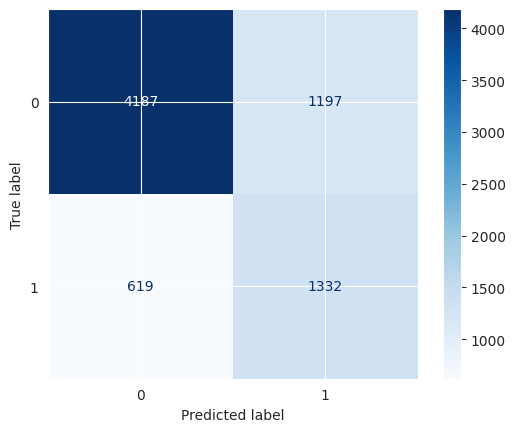

In [18]:
# Exibe a matriz de confusão para o Voting Classifier no conjunto de teste
print("\nMatriz de Confusão - Voting Classifier (Teste):")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_voting, cmap='Blues');

### Stacking Classifier (Classificador por Empilhamento)
#### O Stacking Classifier usa as predições dos modelos base como entrada para um meta-estimador final.
#### Aqui, os mesmos quatro modelos base são usados, e uma Regressão Logística é usada como meta-estimador.
#### A validação cruzada interna (`cv=5`) é usada para gerar as predições dos modelos base que alimentam o meta-estimador.

In [19]:
# Filtra um aviso comum do scikit-learn quando se usa DataFrames com nomes de features em Stacking
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="X has feature names") # Mais específico

In [20]:
# Define o Stacking Classifier
# 'estimators': Lista de modelos base.
# 'final_estimator': O meta-modelo que combina as predições dos modelos base.
# 'cv': Número de folds para a validação cruzada interna usada para gerar as predições dos modelos base.
stacking_classifier = StackingClassifier(
    estimators=[
        ('random_forest', random_forest_pipeline),
        ('xgboost', xgboost_pipeline),
        ('lightgbm', lightgbm_pipeline),
        ('catboost', catboost_pipeline)
    ],
    final_estimator=LogisticRegression(random_state=SEED, class_weight='balanced', solver='liblinear', max_iter=1000), # Meta-estimador
    cv=5, # Validação cruzada interna para gerar predições dos base learners
    n_jobs=-1 # Utiliza todos os processadores disponíveis
)

# Realiza a validação cruzada para o Stacking Classifier
print("\nIniciando validação cruzada para o Stacking Classifier...")
stacking_clf_cv_results = cross_validate(
    stacking_classifier,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), # 5 folds estratificados para a CV externa
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1 # Utiliza todos os processadores disponíveis
)
print("Validação cruzada do Stacking Classifier concluída.")


Iniciando validação cruzada para o Stacking Classifier...


/home/tiagoriosrocha/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/tiagoriosrocha/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/tiagoriosrocha/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/tiagoriosrocha/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/tiagoriosrocha/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/tiag

Validação cruzada do Stacking Classifier concluída.


/home/tiagoriosrocha/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [21]:
# Imprime os resultados da validação cruzada para o Stacking Classifier
print_cv_results(stacking_clf_cv_results)


Resultados da Validação Cruzada:
  Accuracy: Média = 0.7399 | Desvio Padrão = 0.0013
  Precision: Média = 0.5079 | Desvio Padrão = 0.0017
  Recall: Média = 0.7172 | Desvio Padrão = 0.0088
  F1: Média = 0.5947 | Desvio Padrão = 0.0039
  Roc auc: Média = 0.8151 | Desvio Padrão = 0.0037
  Average precision: Média = 0.6431 | Desvio Padrão = 0.0110
------------------------------


In [22]:
# Treina o Stacking Classifier no conjunto completo de treino/validação
print("\nTreinando o Stacking Classifier no conjunto X_train_val...")
stacking_classifier.fit(X_train_val, y_train_val)
print("Treinamento do Stacking Classifier concluído.")

# Faz predições no conjunto de teste
y_pred_stacking = stacking_classifier.predict(X_test)


Treinando o Stacking Classifier no conjunto X_train_val...
Treinamento do Stacking Classifier concluído.


In [23]:
# Avalia o Stacking Classifier no conjunto de teste
print("\nAvaliação do Stacking Classifier no conjunto de teste (X_test):")
print(classification_report(y_test, y_pred_stacking))


Avaliação do Stacking Classifier no conjunto de teste (X_test):
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      5384
           1       0.51      0.71      0.60      1951

    accuracy                           0.74      7335
   macro avg       0.70      0.73      0.70      7335
weighted avg       0.78      0.74      0.75      7335




Matriz de Confusão - Stacking Classifier (Teste):


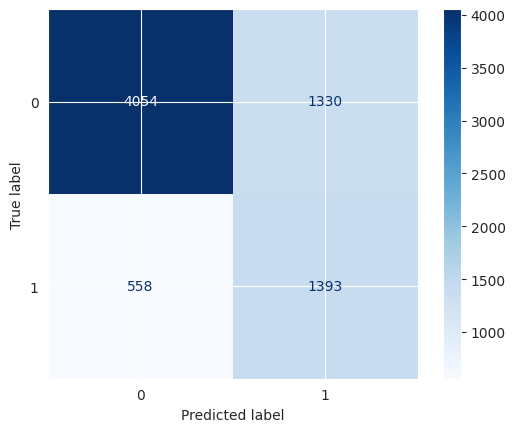

In [24]:
# Exibe a matriz de confusão para o Stacking Classifier no conjunto de teste
print("\nMatriz de Confusão - Stacking Classifier (Teste):")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_stacking, cmap='Blues');